In [21]:
%load_ext autoreload
%autoreload 2

from collections import deque, Counter

import numpy as np

import matplotlib
import matplotlib.animation as animation
import matplotlib.pyplot as plt
from IPython.display import HTML
import PIL.Image

from dm_control import mjcf
from dm_control import viewer

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions import Categorical

import gymnasium as gym

from cartpole3d import CartPole3D



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


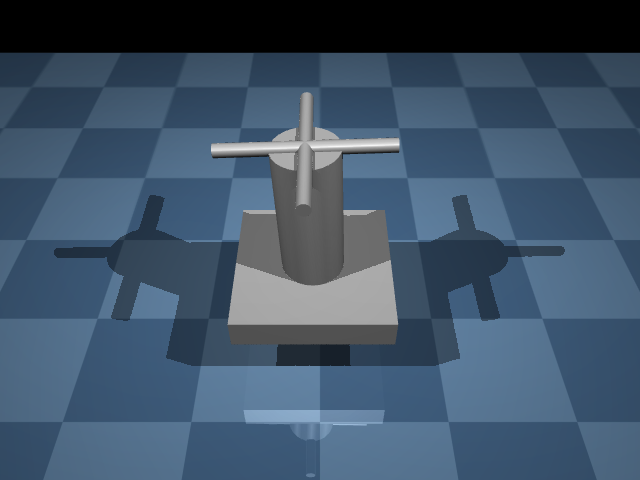

In [2]:
cartpole3d_env = CartPole3D(movement_type='1d')

cartpole3d_env.reset()

for _ in range(100):
    cartpole3d_env.step(10)

cartpole3d_env.render()

In [33]:
torch.set_default_device('cuda:0' if torch.cuda.is_available() else 'cpu')

env = CartPole3D(movement_type='1d')
# env = gym.make("CartPole-v1")
env.reset()

gamma = 0.99


class Policy(nn.Module):
    def __init__(self):
        super(Policy, self).__init__()
        self.affine1 = nn.Linear(4, 128)
        self.dropout = nn.Dropout(p=0.6)
        self.affine2 = nn.Linear(128, 2)

        self.saved_log_probs = []
        self.rewards = []

    def forward(self, x):
        x = self.affine1(x)
        x = self.dropout(x)
        x = F.relu(x)
        action_scores = self.affine2(x)
        return F.softmax(action_scores, dim=1)


policy = Policy()
optimizer = optim.Adam(policy.parameters(), lr=1e-2)
eps = np.finfo(np.float32).eps.item()


def select_action(state):
    state = torch.from_numpy(state).float().unsqueeze(0)
    probs = policy(state)
    m = Categorical(probs)
    action = m.sample()
    policy.saved_log_probs.append(m.log_prob(action))
    return action.item()


def finish_episode():
    R = 0
    policy_loss = []
    returns = deque()
    for r in policy.rewards[::-1]:
        R = r + gamma * R
        returns.appendleft(R)
    returns = torch.tensor(returns)
    returns = (returns - returns.mean()) / (returns.std() + eps)
    for log_prob, R in zip(policy.saved_log_probs, returns):
        policy_loss.append(-log_prob * R)
    optimizer.zero_grad()
    policy_loss = torch.cat(policy_loss).sum()
    policy_loss.backward()
    optimizer.step()
    del policy.rewards[:]
    del policy.saved_log_probs[:]


def translate_action(action):
    # return action
    return (action - 0.5) * 1000

def main():
    running_reward = 0
    best_reward = 0
    for i_episode in range(1000):
        state, _ = env.reset()
        ep_reward = 0
        for t in range(1, 10000):  # Don't infinite loop while learning
            action = select_action(state)
            state, reward, done, _, _ = env.step(translate_action(action))
            # state, reward, done, _, _ = env.step(action)
            
            # if args.render:
            #     env.render()
            
            policy.rewards.append(reward)
            ep_reward += reward
            if done:
                break

        running_reward = 0.05 * ep_reward + (1 - 0.05) * running_reward
        finish_episode()
        
        if ep_reward > best_reward:
            best_reward = ep_reward
            torch.save(policy, 'best.pt')
        
        if i_episode % 1 == 0:
            print(f'Episode {i_episode}\tLast reward: {ep_reward:.2f}\t\tNumber of Actions: {t}')
        if False:
            print("Solved! Running reward is now {} and "
                  "the last episode runs to {} time steps!".format(running_reward, t))
            break
main()

Episode 0	Last reward: 553.96	Average reward: 27.70		Number of Actions: 319
Episode 1	Last reward: 174.82	Average reward: 35.05		Number of Actions: 142
Episode 2	Last reward: 265.62	Average reward: 46.58		Number of Actions: 193
Episode 3	Last reward: 169.91	Average reward: 52.75		Number of Actions: 139
Episode 4	Last reward: 147.57	Average reward: 57.49		Number of Actions: 125
Episode 5	Last reward: 169.91	Average reward: 63.11		Number of Actions: 139
Episode 6	Last reward: 252.33	Average reward: 72.57		Number of Actions: 186
Episode 7	Last reward: 357.67	Average reward: 86.83		Number of Actions: 238
Episode 8	Last reward: 1174.25	Average reward: 141.20		Number of Actions: 505
Episode 9	Last reward: 295.02	Average reward: 148.89		Number of Actions: 208
Episode 10	Last reward: 675.35	Average reward: 175.21		Number of Actions: 362
Episode 11	Last reward: 466.58	Average reward: 189.78		Number of Actions: 285
Episode 12	Last reward: 2557.24	Average reward: 308.15		Number of Actions: 771
Ep

KeyboardInterrupt: 

In [34]:
duration = 5   # (Seconds)
framerate = 30  # (Hz)
video = []
 
last_switch = 0

policy = torch.load('best.pt')

physics = env.physics


state, _ = env.reset()

actions = []

while physics.data.time < duration:
    action = select_action(state)
    actions.append(action)
    state, reward, done, _, _ = env.step(translate_action(action))

    if len(video) < physics.data.time * framerate:
        
        pixels = physics.render(width=640, height=480, camera_id=-1)
        video.append(pixels.copy())
    
 

print(Counter(actions))
display_video(video, framerate)

Counter({0: 1327, 1: 1174})


C:\Users\Brn\AppData\Local\Temp\ipykernel_11220\2271421933.py:7: MatplotlibDeprecationWarning: Auto-close()ing of figures upon backend switching is deprecated since 3.8 and will be removed two minor releases later.  To suppress this warning, explicitly call plt.close('all') first.
  matplotlib.use(orig_backend)  # Switch back to the original backend.


In [35]:
for i in range(0, len(actions) - 100, 100):
    print(Counter(actions[i:i+100]))

Counter({0: 53, 1: 47})
Counter({0: 51, 1: 49})
Counter({0: 51, 1: 49})
Counter({0: 52, 1: 48})
Counter({1: 50, 0: 50})
Counter({1: 53, 0: 47})
Counter({1: 52, 0: 48})
Counter({1: 53, 0: 47})
Counter({1: 53, 0: 47})
Counter({1: 53, 0: 47})
Counter({1: 55, 0: 45})
Counter({1: 53, 0: 47})
Counter({1: 55, 0: 45})
Counter({0: 50, 1: 50})
Counter({1: 54, 0: 46})
Counter({0: 52, 1: 48})
Counter({0: 54, 1: 46})
Counter({0: 59, 1: 41})
Counter({0: 64, 1: 36})
Counter({0: 74, 1: 26})
Counter({0: 74, 1: 26})
Counter({0: 78, 1: 22})
Counter({1: 62, 0: 38})
Counter({1: 54, 0: 46})
Counter({0: 62, 1: 38})


In [19]:
def display_video(frames, framerate=30):
    height, width, _ = frames[0].shape
    dpi = 70
    orig_backend = matplotlib.get_backend()
    matplotlib.use('Agg')  # Switch to headless 'Agg' to inhibit figure rendering.
    fig, ax = plt.subplots(1, 1, figsize=(width / dpi, height / dpi), dpi=dpi)
    matplotlib.use(orig_backend)  # Switch back to the original backend.
    ax.set_axis_off()
    ax.set_aspect('equal')
    ax.set_position([0, 0, 1, 1])
    im = ax.imshow(frames[0])

    def update(frame):
        im.set_data(frame)
        return [im]

    interval = 1000/framerate
    anim = animation.FuncAnimation(fig=fig, func=update, frames=frames,
                                   interval=interval, blit=True, repeat=False)
    return HTML(anim.to_html5_video())

In [ ]:
physics.data.qpos

array([ 0.80046674, -1.047949  ])

In [122]:
np.concatenate([physics.data.qpos, physics.data.qvel])

array([-0.02168953, -0.03073212,  0.38963361, -0.20229654,  0.22114658,
        0.18125404, -1.93815623,  2.08265143])